
# Reproducing Figure 1 — Optimizer Instability (Lyle et al.)

This notebook reproduces the optimizer instability experiment:

- MNIST subset of 5000 images
- Randomized labels
- Relabel every 15,000 training iterations
- MLP with two hidden layers of width 1024
- Compare:
  - Default Adam
  - Tuned Adam
- Log:
  - Accuracy
  - Fraction of dead units
- Recreate Figure 1 style visualization


In [36]:

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, Subset


In [37]:

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", DEVICE)


Device: cpu


In [38]:

class MemorizationMLP(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc1 = nn.Linear(784, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)

        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

    def forward(self, x):

        x = x.view(x.size(0), -1)

        x = self.relu1(self.fc1(x))
        x = self.relu2(self.fc2(x))

        return self.fc3(x)


In [39]:

class PermutedLabelDataset(Dataset):

    def __init__(self, subset):

        self.subset = subset
        self.permute_labels()

    def permute_labels(self):

        self.labels = torch.randint(
            low=0,
            high=10,
            size=(len(self.subset),)
        )

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):

        x, _ = self.subset[idx]

        return x, self.labels[idx]


Sample 0: Label=5


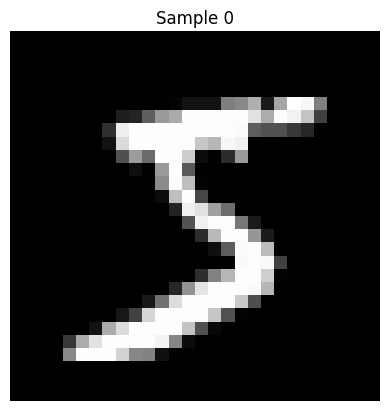

Sample 1: Label=0


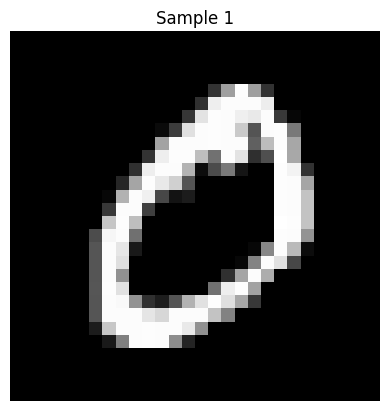

Sample 2: Label=4


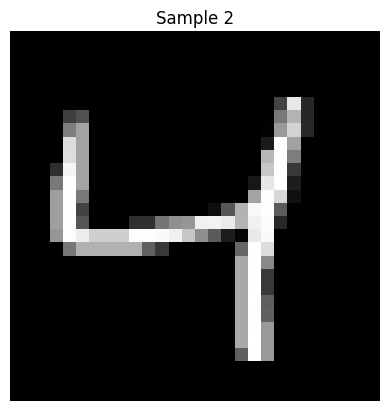

Sample 3: Label=1


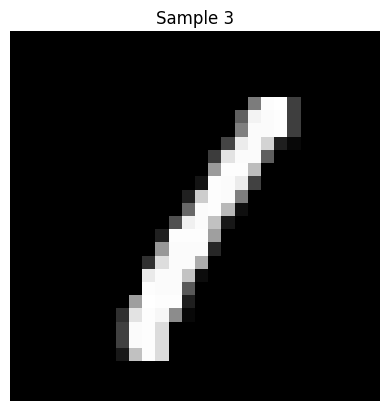

Sample 4: Label=9


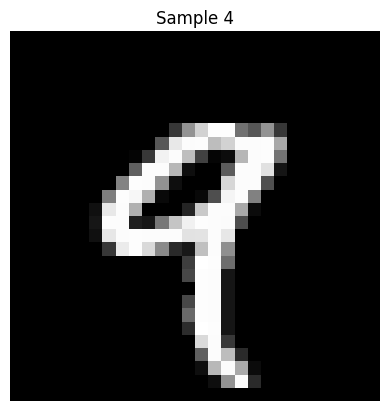

Sample 0: Label=2


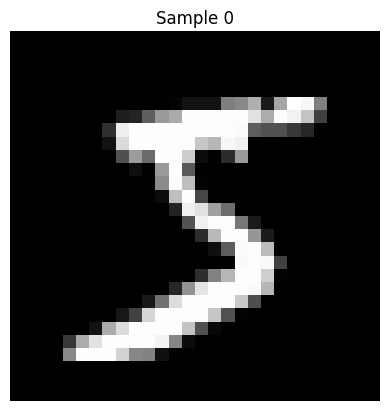

Sample 1: Label=7


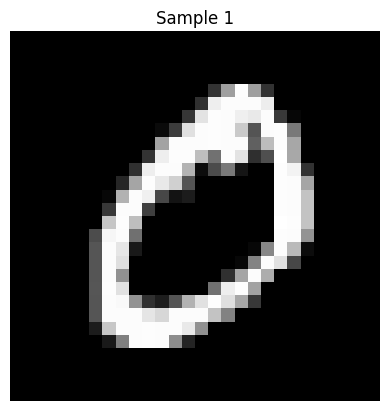

Sample 2: Label=6


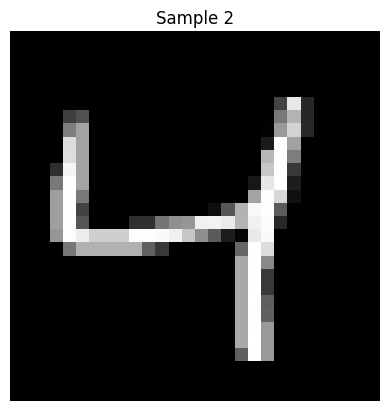

Sample 3: Label=4


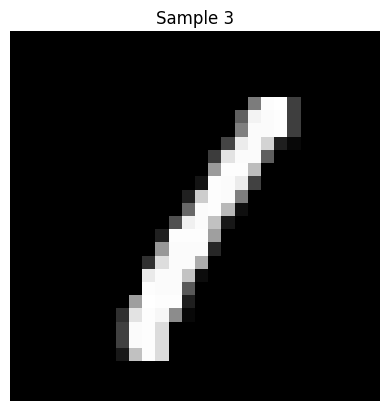

Sample 4: Label=6


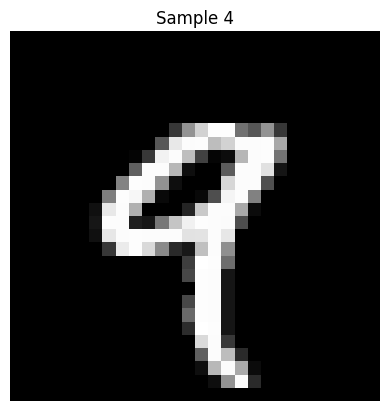

In [40]:

transform = transforms.ToTensor()

mnist = MNIST(
    './data',
    train=True,
    download=True,
    transform=transform
)

subset = Subset(mnist, range(5000))

# show the first few samples of the subset to verify it's correct
for i in range(5):
    img, label = subset[i]
    print(f"Sample {i}: Label={label}")
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Sample {i}")
    plt.axis('off')
    plt.show()

dataset = PermutedLabelDataset(subset)

for i in range(5):
    img, label = dataset[i]
    print(f"Sample {i}: Label={label}")
    plt.imshow(img.squeeze(), cmap='gray')
    plt.title(f"Sample {i}")
    plt.axis('off')
    plt.show()

loader = DataLoader(
    dataset,
    batch_size=128,
    shuffle=True
)




In [41]:

@torch.no_grad()
def compute_accuracy(model, dataloader):

    model.eval()

    correct = 0
    total = 0

    for x, y in dataloader:

        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)

        preds = logits.argmax(1)

        correct += (preds == y).sum().item()
        total += y.size(0)

    return correct / total


In [42]:

@torch.no_grad()
def dead_unit_fraction(model, dataloader):

    model.eval()

    acts1 = []
    acts2 = []

    def h1(module, inp, out):
        acts1.append(out.cpu())

    def h2(module, inp, out):
        acts2.append(out.cpu())

    hook1 = model.relu1.register_forward_hook(h1)
    hook2 = model.relu2.register_forward_hook(h2)

    for x, _ in dataloader:
        model(x.to(DEVICE))

    hook1.remove()
    hook2.remove()

    dead = 0
    total = 0

    # print("Computing dead unit fraction...")

    for acts in [acts1, acts2]:

        acts = torch.cat(acts, dim=0)

        alive = (acts > 0).any(dim=0)

        dead += (~alive).sum().item()
        total += alive.numel()

    # print(f"Dead units: {dead}")
    # print(f"Total units: {total}")

    return dead / total


In [101]:
import torch
from torch.optim import Optimizer

class AdamWithEpsBar(Optimizer):
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-9, eps_bar=0.0):
        defaults = dict(lr=lr, betas=betas, eps=eps, eps_bar=eps_bar)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None): # Added closure support
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr       = group['lr']
            b1, b2   = group['betas']
            eps      = group['eps']
            eps_bar  = group['eps_bar']

            for p in group['params']:
                if p.grad is None:
                    continue

                grad = p.grad
                state = self.state[p]

                # Initialize state
                if len(state) == 0:
                    state['step'] = 0
                    state['m'] = torch.zeros_like(p)   # 1st moment
                    state['v'] = torch.zeros_like(p)   # 2nd moment

                m, v = state['m'], state['v']
                state['step'] += 1
                t = state['step']

                # Moment updates
                m.mul_(b1).add_(grad, alpha=1 - b1)
                v.mul_(b2).addcmul_(grad, grad, value=1 - b2)

                # Bias correction
                bias_correction1 = 1 - b1 ** t
                bias_correction2 = 1 - b2 ** t

                # Compute step size scaling factor
                step_size = lr / bias_correction1

                # Correct and scale variance safely without mutating state['v']
                # .clone() ensures we don't accidentally corrupt original state memory
                v_hat = (v / bias_correction2).clone()

                # Math: denom = sqrt(v_hat + eps_bar) + eps
                denom = v_hat.add_(eps_bar).sqrt_().add_(eps)

                # Efficiently apply the update directly to the parameters: p = p - step_size * (m / denom)
                p.addcdiv_(m, denom, value=-step_size)

        return loss

In [102]:

model_default = MemorizationMLP().to(DEVICE)
model_tuned = MemorizationMLP().to(DEVICE)

optimizer_default =torch.optim.Adam(
    model_default.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-9)


optimizer_tuned = AdamWithEpsBar(
    model_tuned.parameters(),
    lr=1e-3,
    betas=(0.9, 0.999),
    eps=1e-9,
    eps_bar=1e-3
)

criterion = nn.CrossEntropyLoss()


In [103]:

TOTAL_ITERATIONS = 90000
TASK_INTERVAL = 15000
LOG_INTERVAL = 100

steps = []

acc_default = []
acc_tuned = []

dead_default = []
dead_tuned = []

task_boundaries = []


In [104]:

def train_one_step(model, optimizer, x, y):

    model.train()

    optimizer.zero_grad()

    logits = model(x)

    loss = criterion(logits, y)

    loss.backward()

    optimizer.step()

    return loss.item()


In [106]:
from tqdm import tqdm
# Correct: one batch per step
data_iter = iter(loader)

for step in tqdm(range(TOTAL_ITERATIONS)):
    try:
        x, y = next(data_iter)
    except StopIteration:
        data_iter = iter(loader)
        x, y = next(data_iter)
    x, y = x.to(DEVICE), y.to(DEVICE)
    train_one_step(model_default, optimizer_default, x, y)
    train_one_step(model_tuned, optimizer_tuned, x, y)

    if step % LOG_INTERVAL == 0:

        test_loader = DataLoader(
            Subset(dataset, range(4096)),
            batch_size=128,
            shuffle=False
        )

        steps.append(step)


        acc_tuned.append(
            compute_accuracy(model_tuned, test_loader)
        )
        acc_default.append(
            compute_accuracy(model_default, test_loader)
        )
        # print(f"Step {step}: Default Acc = {acc_default[-1]:.4f}", end='; ')

        # print(f"Step {step}: Tuned Acc = {acc_tuned[-1]:.4f}")

        dead_default.append(
            dead_unit_fraction(model_default, test_loader)
        )

        dead_tuned.append(
            dead_unit_fraction(model_tuned, test_loader)
        )

    if step > 0 and step % TASK_INTERVAL == 0:

        dataset.permute_labels()
        loader = DataLoader(
            dataset,
            batch_size=128,
            shuffle=True
        )

        task_boundaries.append(step)

        print(f'Task boundary at {step}')




 17%|█▋        | 15020/90000 [03:08<19:30, 64.04it/s] 

Task boundary at 15000


 33%|███▎      | 30012/90000 [07:09<31:19, 31.91it/s] 

Task boundary at 30000


 50%|█████     | 45012/90000 [11:45<19:59, 37.51it/s]

...

 67%|██████▋   | 60010/90000 [16:29<18:29, 27.04it/s]

Task boundary at 60000


 83%|████████▎ | 75010/90000 [21:12<06:51, 36.40it/s]

Task boundary at 75000


100%|██████████| 90000/90000 [25:59<00:00, 57.73it/s]


In [107]:
len(steps)

900

In [108]:
len(acc_tuned)

900

In [109]:
len(acc_default)

900

In [110]:
len(dead_default)

900

In [111]:
len(dead_tuned)

900

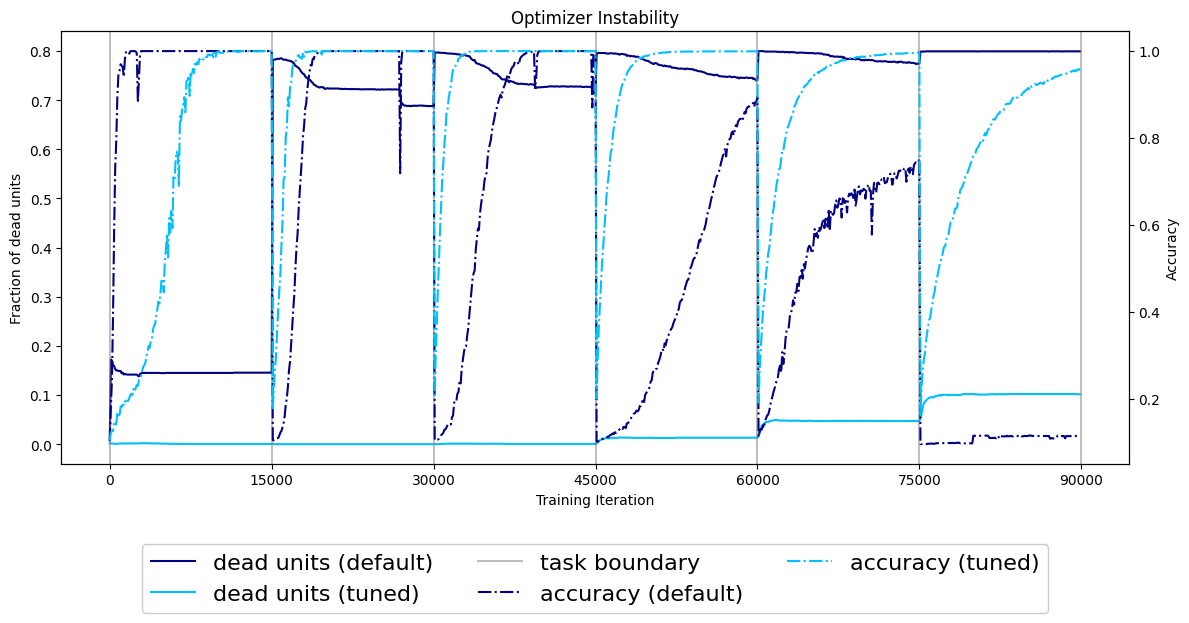

In [113]:

fig, ax1 = plt.subplots(figsize=(12,6))

ax2 = ax1.twinx()

line1 = ax1.plot(
    steps,
    dead_default,
    label='dead units (default)',
    color='navy'
)

line2 = ax1.plot(
    steps,
    dead_tuned,
    label='dead units (tuned)',
    color='deepskyblue'
)

line3 = ax2.plot(
    steps,
    acc_default,
    '-.',
    label='accuracy (default)',
    color='navy'
)

line4 = ax2.plot(
    steps,
    acc_tuned,
    '-.',
    label='accuracy (tuned)',
    color='deepskyblue'
)

boundary_ticks = [0] + task_boundaries + [TOTAL_ITERATIONS]
for b in boundary_ticks:

    ax1.axvline(
        b,
        color='gray',
        alpha=0.5,
        label='task boundary' if b == task_boundaries[0] else None
    )

ax1.set_ylabel('Fraction of dead units')
ax2.set_ylabel('Accuracy')

ax1.set_xlabel('Training Iteration')
ax1.set_xticks(boundary_ticks)

plt.title('Optimizer Instability')

# Collect handles from both axes
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()

handles = handles1 + handles2
labels = labels1 + labels2

# Legend below the figure
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    fancybox=True,
    framealpha=1.0,
    fontsize=16

)
plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()
